In [1]:
%matplotlib ipympl
from pylab import *
import control as ctrl
s = ctrl.tf("s")

## 1. Aufgabe - Einlesen der Daten

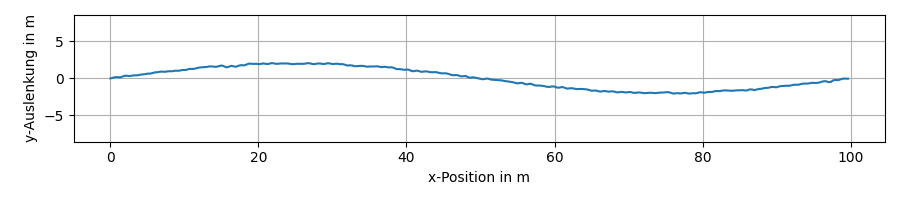

In [2]:
import pandas as pd
df = pd.read_csv('oberflaechen_profil.csv', index_col=0)

t = df.index
y = df['y-Auslenkung']
x = df['x-Position']
figure(figsize=(9,2))
plot(x,y); axis('equal'); grid(); xlabel('x-Position in m'); ylabel('y-Auslenkung in m'); tight_layout()

## 2. Aufgabe - Mit welcher Geschwindigkeit bewegt sich das Fahrzeug?

Geschwindigkeit : 60.0 km/h


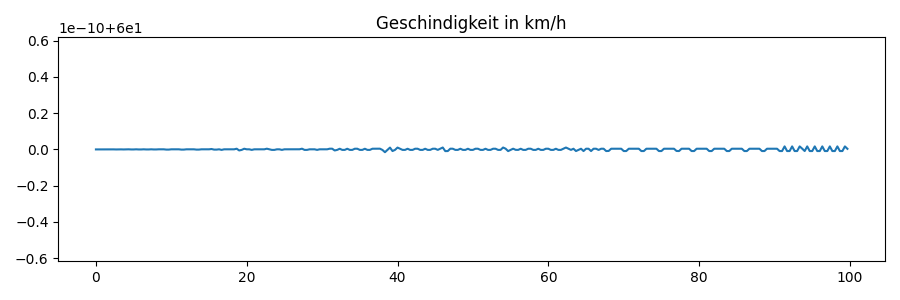

In [3]:
vx = gradient(x) / gradient(t) # dx/dt

figure(figsize=(9,3)); title('Geschindigkeit in km/h')
plot(x,vx*3.6); tight_layout()

print(f"Geschwindigkeit : {(vx.mean()*3.6):2.1f} km/h")

## 3. Aufgabe - Welche Beschleunigungen wirken auf das Fahrzeug (ohne Federung) in vertikaler Richtung?

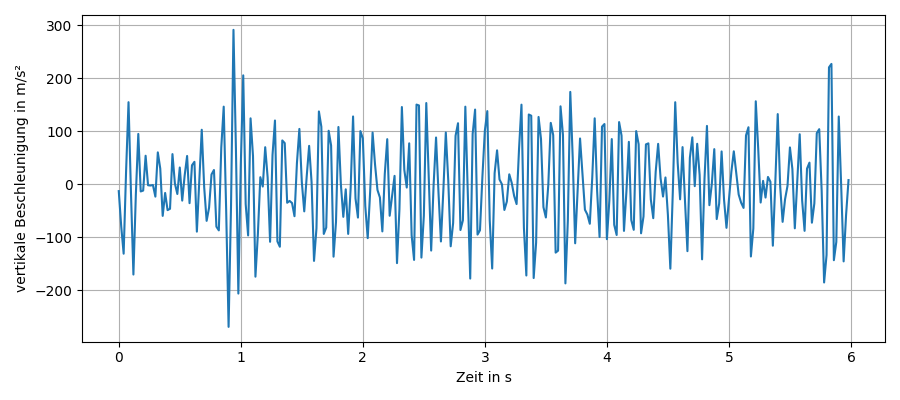

In [4]:
dt = t[1] - t[0]      # Äquidistante Zeitschritte

dy = gradient(y)/dt
ddy = gradient(dy)/dt


figure(figsize=(9,4))
plot(t,ddy); grid(); xlabel('Zeit in s'); ylabel('vertikale Beschleunigung in m/s²'); tight_layout()

## 4. Aufgabe - Bestimmung der Frequenzanteile in der Radauslenkung. Welche Frequenzen haben die Unebenheiten?

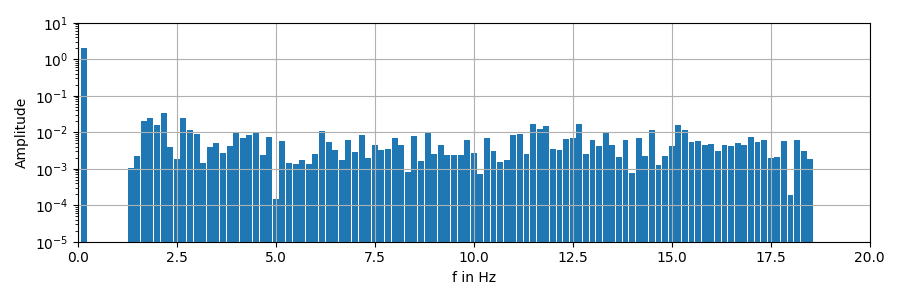

In [5]:
f = rfftfreq(len(t), dt)
Y = rfft(y, norm='forward')*2

figure(figsize=(9,3))
bar(f, abs(Y), width=0.15)
grid(); xlabel('f in Hz'); ylabel('Amplitude')
ylim(1e-5,10); xlim(0,20); yscale('log'); tight_layout()

## 5. Aufgabe - Wie lautet das Bodediagram bei der angepassten Federung?

In [6]:
m =  2        # Masse
w0 = 2*pi* 1  # Resonanzfrequenz (ungedämpft)
D =  0.2      # Dämpfungsgrad
    
k =  w0**2 * m      # Federkonstante
d =  D*2*sqrt(m*k)  # Dämpfungskonstante

G = (s*d + k)/(m*s**2 + s*d +k) # Feder-Masse-Dämpfer-Übertragungsfunktion

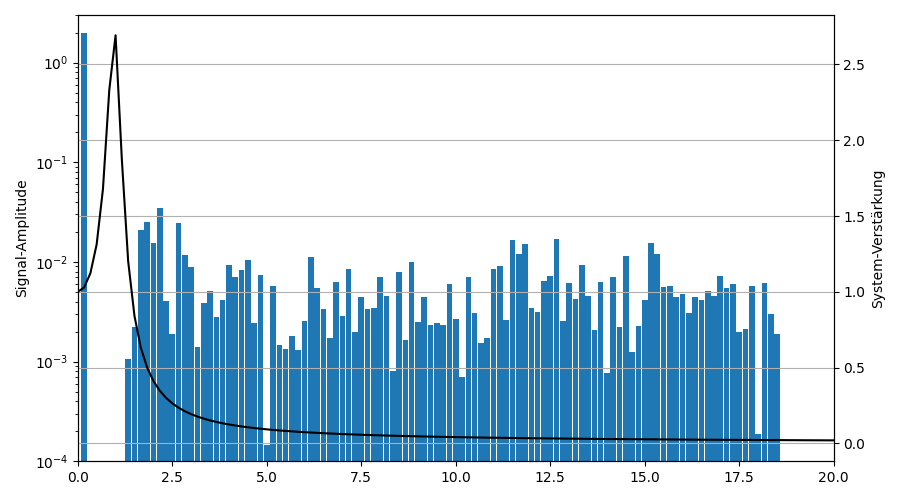

In [7]:
Ag,Pg,_ = G.frequency_response(omega=2*pi*f)

figure(figsize=(9,5))
bar(f,abs(Y), width=0.15); ylabel('Signal-Amplitude'); yscale('log'); ylim(0.0001,3); twinx()
plot(f,Ag, 'k'); ylabel('System-Verstärkung'); xlabel('Frequenz')
grid(); xlim(0,20); tight_layout()

## 6. Aufgabe - Berechnen Sie die Einfederung und die vertikale Beschleunigung des Fahrzeugs.

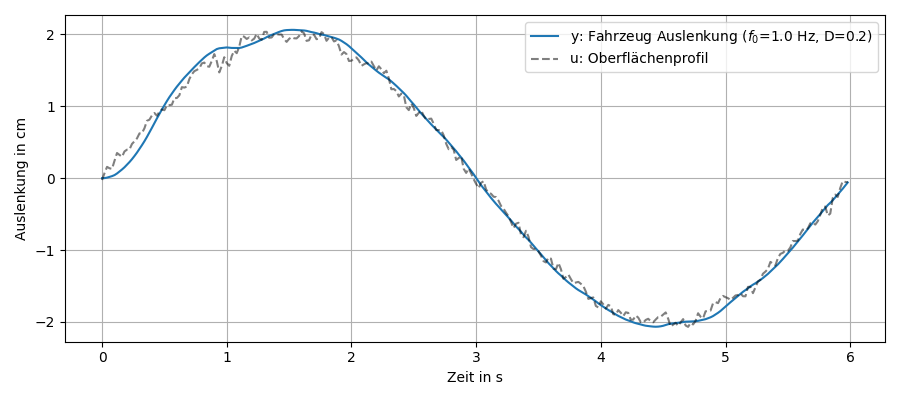

In [8]:
t, y2 = ctrl.forced_response(G, t, y)     # Systemantwort auf die Eingabe (Auslenkung) simulieren

figure(figsize=(9,4)); xlabel('Zeit in s'); ylabel('Auslenkung in cm');
plot(t,y2, label=f'y: Fahrzeug Auslenkung ($f_0$={w0/2/pi:2.1f} Hz, D={D:2.1f})')
plot(t,y, 'k--', alpha=0.5, label='u: Oberflächenprofil')
legend(); grid(); tight_layout()

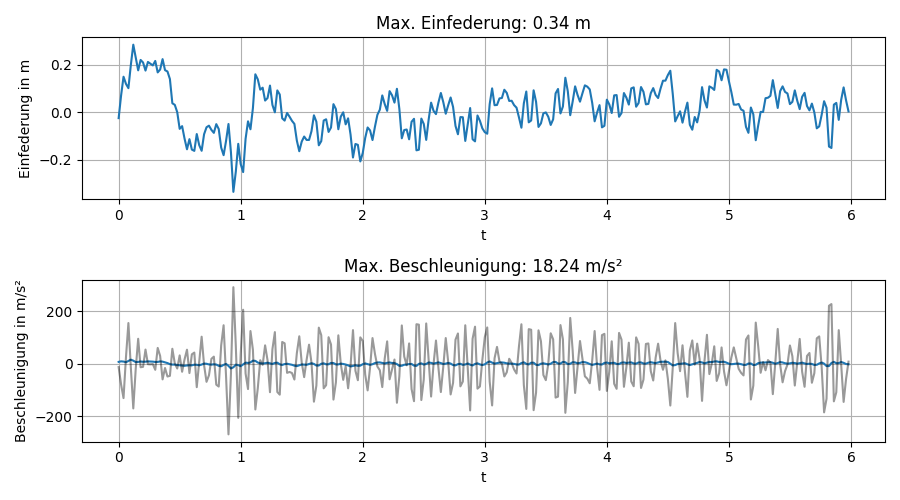

In [9]:
e2 = y-y2
ddy2 = gradient(gradient(y2))/dt**2

figure(figsize=(9,5))
subplot(211); title(f"Max. Einfederung: {max(abs(e2)):2.2f} m")
plot(t,e2); grid(); xlabel('t'); ylabel('Einfederung in m')
subplot(212); title(f"Max. Beschleunigung: {max(abs(ddy2)):2.2f} m/s²")
plot(t,ddy2); grid(); xlabel('t'); ylabel('Beschleunigung in m/s²')
plot(t,ddy, 'k-', alpha=0.4); xlabel('t'); tight_layout()

## 7. Aufgabe - Gibt es eine Auslegung für die Fahrzeugfederung bei der die  maximale vertikale Beschleunigung weniger als 25 m/s² und die Einfederungung weniger als 27 cm betragen?

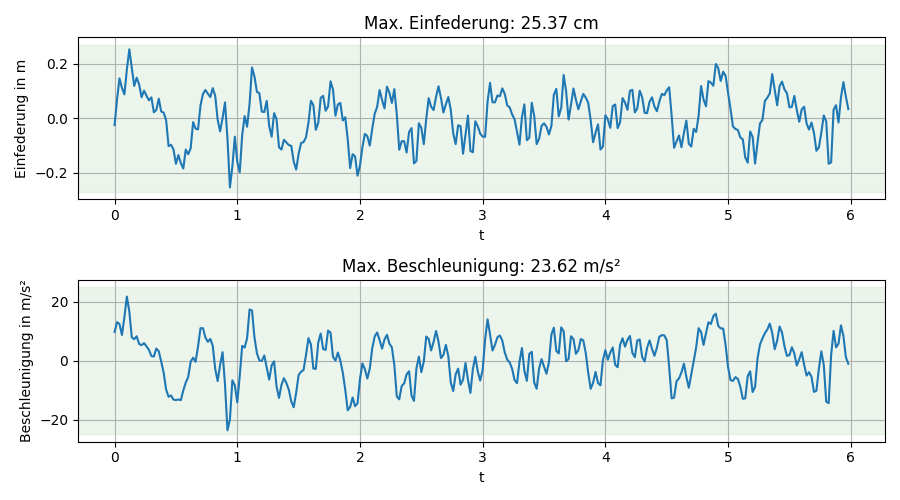

In [10]:
soll_max_a = 25
soll_max_e = 0.27

w0 = 2*pi* 1.4  # Resonanzfrequenz (ungedämpft)
D =  0.19      # Dämpfungsgrad
    
k =  w0**2 * m      # Federkonstante
d =  D*2*sqrt(m*k)  # Dämpfungskonstante

G = (s*d + k)/(m*s**2 + s*d +k) # Feder-Masse-Dämpfer-Übertragungsfunktion

t, y2 = ctrl.forced_response(G, t, y)     # Systemantwort auf die Eingabe (Auslenkung) simulieren

e2 = y-y2
ddy2 = np.gradient(np.gradient(y2))/dt**2

figure(figsize=(9,5))
subplot(211); title(f"Max. Einfederung: {max(abs(e2*100)):2.2f} cm")
plot(t,e2); grid(); xlabel('t'); ylabel('Einfederung in m')
axhspan(-soll_max_e, soll_max_e, color='g', alpha=0.08)
subplot(212); title(f"Max. Beschleunigung: {max(abs(ddy2)):2.2f} m/s²")
plot(t,ddy2); grid(); xlabel('t'); ylabel('Beschleunigung in m/s²')
xlabel('t'); tight_layout()
axhspan(-soll_max_a, soll_max_a, color='g', alpha=0.08)

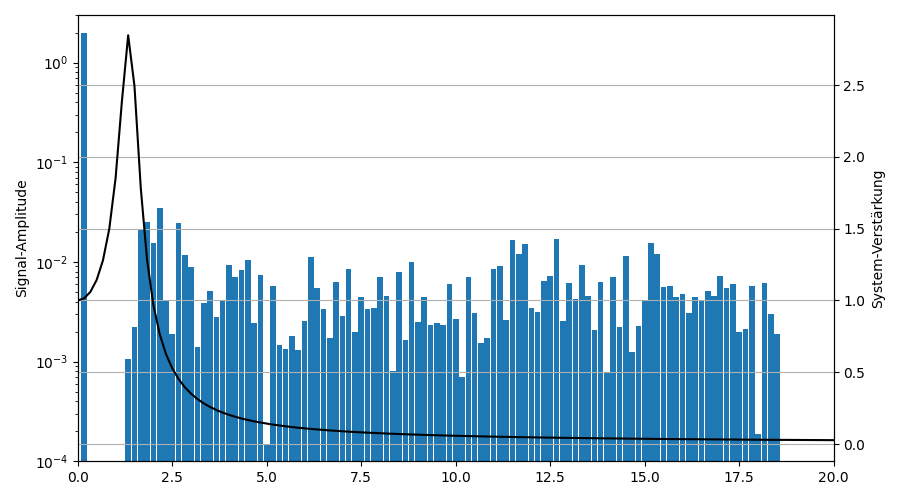

In [11]:
Ag,Pg,_ = G.frequency_response(omega=2*pi*f)

figure(figsize=(9,5))
bar(f,abs(Y), width=0.15); ylabel('Signal-Amplitude'); yscale('log'); ylim(0.0001,3); twinx()
plot(f,Ag, 'k'); ylabel('System-Verstärkung'); xlabel('Frequenz')
grid(); xlim(0,20); tight_layout()

## Mit scipy.optimize:

In [12]:
import scipy as sci

soll_max_a = 0.25
soll_max_e = 0.27

def opt_federung(params):
    f0, D = params
    w0 = 2*pi*f0
    k =  w0**2 * m      # Federkonstante
    d =  D*2*sqrt(m*k)  # Dämpfungskonstante

    G = (s*d + k)/(m*s**2 + s*d +k) # Feder-Masse-Dämpfer-Übertragungsfunktion

    _, y2 = ctrl.forced_response(G, t, y)     # Systemantwort auf die Eingabe (Auslenkung) simulieren

    e2 = y-y2
    ddy2 = np.gradient(np.gradient(y2))/dt**2
    
    max_e = max(abs(e2))
    max_a = max(abs(ddy2))
    
    # Fehler ist summe der relativen Abweichung => Optimierungskriterium
    err = max([max_e/soll_max_e ,max_a/soll_max_a])
    return err


# Grenzen für f0 und D definieren
bounds = [(0, 2), (0, 1)] 

best_result = None
best_err = np.inf
for _ in range(1):  # 10 zufällige Startpunkte
    start_params = [np.random.uniform(low, high) for low, high in bounds]
    result = sci.optimize.minimize(opt_federung, start_params, method='SLSQP', bounds=bounds)
    if result.fun < best_err:
        best_err = result.fun
        best_result = result
        
# Ausgabe der optimalen Parameter
opt_f0, opt_D = result.x
print(f"Optimierte Werte gefunden: f0 = {opt_f0:0.3f}; D = {opt_D:0.3f}")
print(result)

Optimierte Werte gefunden: f0 = 0.000; D = 0.000
 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 7.659109941407954
       x: [ 0.000e+00  0.000e+00]
     nit: 2
     jac: [ 2.348e-05  0.000e+00]
    nfev: 6
    njev: 2


/opt/conda/lib/python3.12/site-packages/scipy/signal/_lti_conversion.py:74: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  num, den = normalize(num, den)   # Strips zeros, checks arrays


## Visualisierung als 2D Fläche

In [13]:
def opt_federung2d(params):
    f0, D = params
    w0 = 2*pi*f0
    k =  w0**2 * m      # Federkonstante
    d =  D*2*sqrt(m*k)  # Dämpfungskonstante

    G = (s*d + k)/(m*s**2 + s*d +k) # Feder-Masse-Dämpfer-Übertragungsfunktion

    _, y2 = ctrl.forced_response(G, t, y)     # Systemantwort auf die Eingabe (Auslenkung) simulieren

    e2 = y-y2
    ddy2 = np.gradient(np.gradient(y2))/dt**2
    
    max_e = max(abs(e2))
    max_a = max(abs(ddy2))
    
    return (max_e, max_a)

# Erstellen eines Meshgrids innerhalb der Grenzen
f0_vals = np.linspace(bounds[0][0], bounds[0][1], 31)  # 31 Punkte für w0
D_vals = np.linspace(bounds[1][0], bounds[1][1], 31)  # 31 Punkte für D
F0, D = np.meshgrid(f0_vals, D_vals)

# Initialisierung der Arrays für max_e und max_a
Max_e = np.zeros(F0.shape)
Max_a = np.zeros(D.shape)

# Durchlaufen des Grids und Berechnung von max_e und max_a
for i in range(F0.shape[0]):
    for j in range(F0.shape[1]):
        max_e, max_a = opt_federung2d([F0[i, j], D[i, j]])
        Max_e[i, j] = max_e
        Max_a[i, j] = max_a

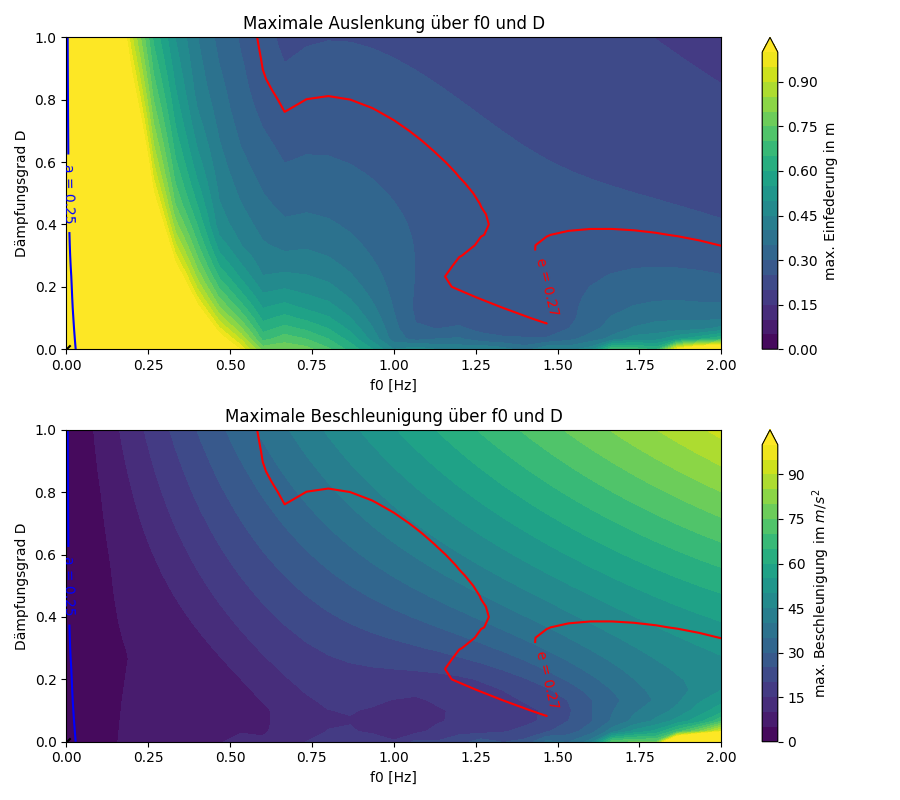

In [14]:
# Plotten von max_e mit der soll_max_e-Linie
figure(figsize=(9, 8))
subplot(211)
contourf(F0, D, Max_e, levels=linspace(0,1,21), extend='max')
colorbar(label='max. Einfederung in m', )
CS_a = plt.contour(F0, D, Max_a, levels=[soll_max_a], colors='blue')
clabel(CS_a, fmt='a = %.2f', inline=True)
CS_e = contour(F0, D, Max_e, levels=[soll_max_e], colors='red')
clabel(CS_e, fmt='e = %.2f', inline=True)
scatter( opt_f0, opt_D, c='k', marker='x')
xlabel('f0 [Hz]')
ylabel('Dämpfungsgrad D')
title('Maximale Auslenkung über f0 und D')


# Plotten von max_a mit der soll_max_a-Linie
subplot(212)
plt.contourf(F0, D, Max_a, levels=linspace(0,100,21), extend='max')  
colorbar(label='max. Beschleunigung im $m/s^2$')
CS_a = plt.contour(F0, D, Max_a, levels=[soll_max_a], colors='blue')
clabel(CS_a, fmt='a = %.2f', inline=True)
CS_e = contour(F0, D, Max_e, levels=[soll_max_e], colors='red')
clabel(CS_e, fmt='e = %.2f', inline=True)
scatter( opt_f0, opt_D, c='k', marker='x')
xlabel('f0 [Hz]')
ylabel('Dämpfungsgrad D')
title('Maximale Beschleunigung über f0 und D')
tight_layout()